### Load necesary Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

%matplotlib inline

### Load Dataset

In [2]:
df = pd.read_csv("quick_commerce_data_raw.csv")
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702.33750,19.182,11.97,12.0,Dairy,Wallet,2.1,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007.30000,19.644,12.74,10.0,Snacks,Cash on Delivery,2.3,0,3.2
2,1000003,Flipkart Minutes,Mumbai,18,1211.66000,16.910,4.85,NaN,Personal Care,Cash on Delivery,3.3,0,3.8
3,1000004,Swiggy Instamart,Delhi,23,1179.05925,5.864,6.44,2.0,Dairy,Credit Card,5.0,1,5.0
4,1000005,Dunzo,Mumbai,44,586.02550,12.470,2.45,13.0,Household,Wallet,3.7,0,4.8


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   Order_ID                 1000000 non-null  int64  
 1   Company                  1000000 non-null  object 
 2   City                     948000 non-null   object 
 3   Customer_Age             1000000 non-null  int64  
 4   Order_Value              1000000 non-null  float64
 5   Delivery_Time_Min        1000000 non-null  float64
 6   Distance_Km              1000000 non-null  float64
 7   Items_Count              965000 non-null   float64
 8   Product_Category         1000000 non-null  object 
 9   Payment_Method           1000000 non-null  object 
 10  Customer_Rating          953000 non-null   float64
 11  Discount_Applied         1000000 non-null  int64  
 12  Delivery_Partner_Rating  895863 non-null   float64
dtypes: float64(6), int64(3), object(4)
memory u

In [4]:
# Summary statistics of the dataset
df.describe()

,Order_ID,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
count,1.000000e+06,1000000.000000,1000000.000000,1000000.000000,1000000.000000,965000.000000,953000.000000,1000000.000000,895863.000000
mean,1.500000e+06,38.470387,571.643584,16.452412,7.750231,9.998317,3.042072,0.400883,3.749257
std,2.886753e+05,12.118520,382.784520,6.257172,4.186665,5.478725,1.186872,0.490078,0.722121
min,1.000001e+06,18.000000,50.000000,5.000000,0.500000,1.000000,1.000000,0.000000,2.500000
25%,1.250001e+06,28.000000,287.840150,12.368000,4.130000,5.000000,2.000000,0.000000,3.100000
50%,1.500000e+06,38.000000,531.324600,16.342000,7.740000,10.000000,3.000000,0.000000,3.700000
75%,1.750000e+06,49.000000,796.182500,20.196000,11.380000,15.000000,4.000000,1.000000,4.400000
max,2.000000e+06,59.000000,13877.325000,40.000000,15.000000,19.000000,5.000000,1.000000,5.000000


In [5]:
# Cheking for missing values
df.isnull().sum()

Order_ID                        0
Company                         0
City                        52000
Customer_Age                    0
Order_Value                     0
Delivery_Time_Min               0
Distance_Km                     0
Items_Count                 35000
Product_Category                0
Payment_Method                  0
Customer_Rating             47000
Discount_Applied                0
Delivery_Partner_Rating    104137
dtype: int64

In [6]:
df[df.isna().any(axis=1)]

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
2,1000003,Flipkart Minutes,Mumbai,18,1211.66000,16.910,4.85,NaN,Personal Care,Cash on Delivery,3.3,0,3.8
6,1000007,Blinkit,Bengluru,37,516.86480,18.476,12.46,19.0,Snacks,Debit Card,2.8,0,NaN
17,1000018,Zepto,Delhi,23,1041.42975,5.000,14.74,18.0,Snacks,Wallet,NaN,1,NaN
21,1000022,Blinkit,NaN,41,716.89860,17.804,11.34,7.0,Beverages,Credit Card,2.7,1,3.6
22,1000023,Jio Mart,Delhi,48,50.00000,8.498,0.83,3.0,Snacks,Cash on Delivery,3.1,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
999966,1999967,Dunzo,NaN,39,783.89250,18.820,14.70,NaN,Household,Wallet,3.1,1,4.9
999975,1999976,Amazon Now,Bengluru,34,515.89380,21.294,10.49,10.0,Fruits & Vegetables,Wallet,NaN,1,3.0
999981,1999982,Amazon Now,NaN,33,939.34470,21.080,11.80,18.0,Dairy,Wallet,3.2,1,4.4
999983,1999984,Swiggy Instamart,Hyderabad,42,50.00000,13.386,2.31,2.0,Groceries,Wallet,NaN,0,3.2


### Remove Rows having Null Values

In [7]:
# Droping rows with missing values in "City" column
df = df.dropna(subset=["City"])

In [8]:
df.shape

(948000, 13)

In [9]:
df.isnull().sum()

Order_ID                       0
Company                        0
City                           0
Customer_Age                   0
Order_Value                    0
Delivery_Time_Min              0
Distance_Km                    0
Items_Count                33228
Product_Category               0
Payment_Method                 0
Customer_Rating            44575
Discount_Applied               0
Delivery_Partner_Rating    98694
dtype: int64

In [10]:
# Filling missing values in "Items_Count" column with the mode
df["Items_Count"] = df["Items_Count"].fillna(df["Items_Count"].mode()[0])
df.isnull().sum()

Order_ID                       0
Company                        0
City                           0
Customer_Age                   0
Order_Value                    0
Delivery_Time_Min              0
Distance_Km                    0
Items_Count                    0
Product_Category               0
Payment_Method                 0
Customer_Rating            44575
Discount_Applied               0
Delivery_Partner_Rating    98694
dtype: int64

### Fill Null Values with group-wise Mean/Median

In [11]:
# Use Group-wise mean imputation
df["Customer_Rating"] = df.groupby("Company")["Customer_Rating"].transform(lambda x:x.fillna(x.mean()))
df.isna().sum()

Order_ID                       0
Company                        0
City                           0
Customer_Age                   0
Order_Value                    0
Delivery_Time_Min              0
Distance_Km                    0
Items_Count                    0
Product_Category               0
Payment_Method                 0
Customer_Rating                0
Discount_Applied               0
Delivery_Partner_Rating    98694
dtype: int64

In [12]:
df["Delivery_Partner_Rating"] = df.groupby("Delivery_Time_Min")["Delivery_Partner_Rating"].transform(lambda y:y.fillna(y.mean()))
df.isna().sum()


Order_ID                    0
Company                     0
City                        0
Customer_Age                0
Order_Value                 0
Delivery_Time_Min           0
Distance_Km                 0
Items_Count                 0
Product_Category            0
Payment_Method              0
Customer_Rating             0
Discount_Applied            0
Delivery_Partner_Rating    76
dtype: int64

In [13]:
df["Delivery_Partner_Rating"].fillna(df["Delivery_Partner_Rating"].mean(), inplace=True)
df.isna().sum()

C:\Users\user\AppData\Local\Temp\ipykernel_22996\420677552.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Delivery_Partner_Rating"].fillna(df["Delivery_Partner_Rating"].mean(), inplace=True)


Order_ID                   0
Company                    0
City                       0
Customer_Age               0
Order_Value                0
Delivery_Time_Min          0
Distance_Km                0
Items_Count                0
Product_Category           0
Payment_Method             0
Customer_Rating            0
Discount_Applied           0
Delivery_Partner_Rating    0
dtype: int64

### Remove Outliers

<Axes: >

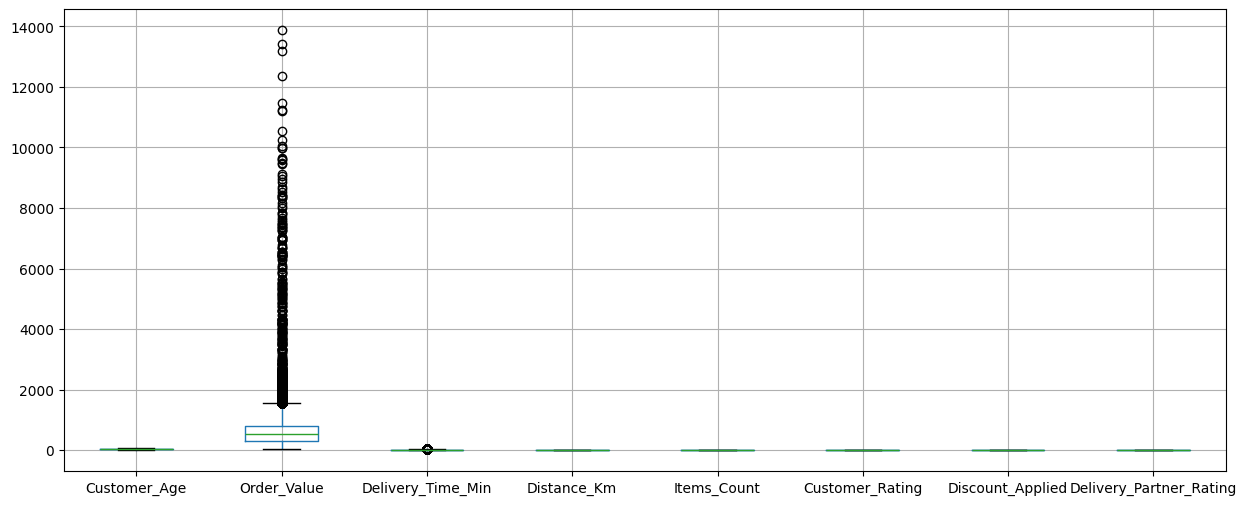

In [14]:
# Box plot
plt.figure(figsize=(15,6))
df.drop(columns=["Order_ID"]).boxplot()

In [15]:
# df["Order_Value"] = df["Order_Value"].clip(upper=2500)

# 2) Filtering
df = df[df["Order_Value"] <=2500 ]

<Axes: >

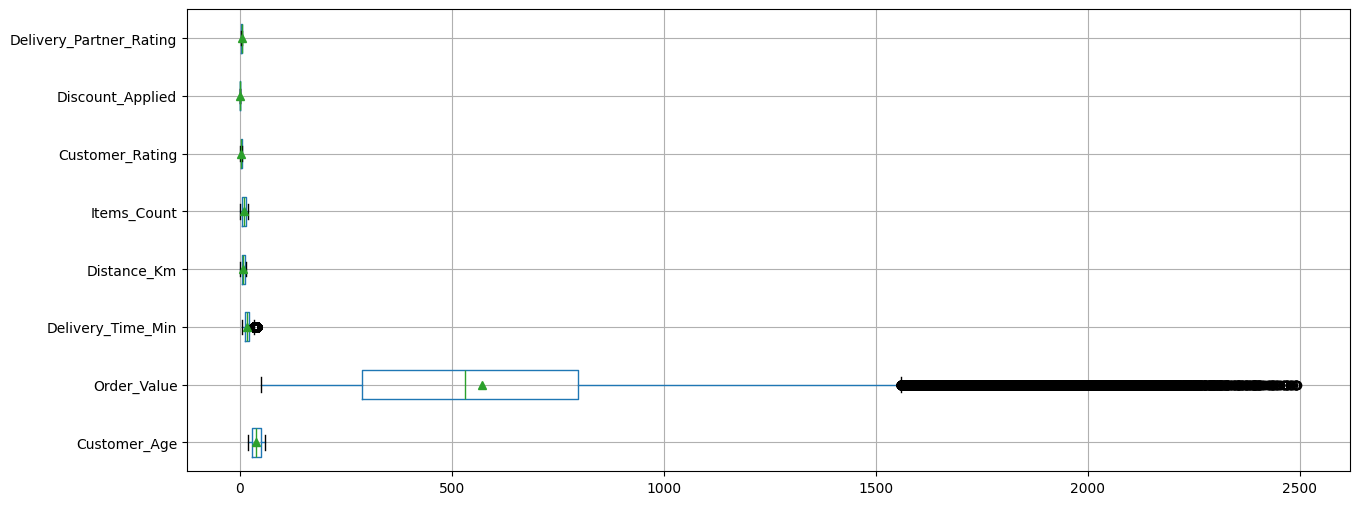

In [16]:
plt.figure(figsize=(15,6))
df.drop(columns=["Order_ID"]).boxplot(vert=False,showmeans=True)

In [17]:
df.describe()

,Order_ID,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
count,9.477520e+05,947752.000000,947752.000000,947752.000000,947752.000000,947752.000000,947752.000000,947752.000000,947752.000000
mean,1.500028e+06,38.471165,570.912385,16.502070,7.750046,10.313292,3.042843,0.400786,3.749173
std,2.887273e+05,12.118982,374.174789,6.330106,4.186990,5.630770,1.161112,0.490058,0.684365
min,1.000001e+06,18.000000,50.000000,5.000000,0.500000,1.000000,1.000000,0.000000,2.500000
25%,1.249939e+06,28.000000,287.923000,12.362000,4.130000,5.000000,2.100000,0.000000,3.200000
50%,1.500026e+06,38.000000,531.674100,16.384000,7.750000,10.000000,3.015637,0.000000,3.753051
75%,1.750145e+06,49.000000,796.556650,20.302000,11.380000,15.000000,4.000000,1.000000,4.300000
max,2.000000e+06,59.000000,2492.435250,40.000000,15.000000,19.000000,5.000000,1.000000,5.000000


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 947752 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Order_ID                 947752 non-null  int64  
 1   Company                  947752 non-null  object 
 2   City                     947752 non-null  object 
 3   Customer_Age             947752 non-null  int64  
 4   Order_Value              947752 non-null  float64
 5   Delivery_Time_Min        947752 non-null  float64
 6   Distance_Km              947752 non-null  float64
 7   Items_Count              947752 non-null  float64
 8   Product_Category         947752 non-null  object 
 9   Payment_Method           947752 non-null  object 
 10  Customer_Rating          947752 non-null  float64
 11  Discount_Applied         947752 non-null  int64  
 12  Delivery_Partner_Rating  947752 non-null  float64
dtypes: float64(6), int64(3), object(4)
memory usage: 101.2+ MB


### Change Column Data-type

In [19]:
df["Order_ID"] = df["Order_ID"].astype(str)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 947752 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Order_ID                 947752 non-null  object 
 1   Company                  947752 non-null  object 
 2   City                     947752 non-null  object 
 3   Customer_Age             947752 non-null  int64  
 4   Order_Value              947752 non-null  float64
 5   Delivery_Time_Min        947752 non-null  float64
 6   Distance_Km              947752 non-null  float64
 7   Items_Count              947752 non-null  float64
 8   Product_Category         947752 non-null  object 
 9   Payment_Method           947752 non-null  object 
 10  Customer_Rating          947752 non-null  float64
 11  Discount_Applied         947752 non-null  int64  
 12  Delivery_Partner_Rating  947752 non-null  float64
dtypes: float64(6), int64(2), object(5)
memory usage: 101.2+ MB


In [20]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702.33750,19.182,11.97,12.0,Dairy,Wallet,2.1,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007.30000,19.644,12.74,10.0,Snacks,Cash on Delivery,2.3,0,3.2
2,1000003,Flipkart Minutes,Mumbai,18,1211.66000,16.910,4.85,19.0,Personal Care,Cash on Delivery,3.3,0,3.8
3,1000004,Swiggy Instamart,Delhi,23,1179.05925,5.864,6.44,2.0,Dairy,Credit Card,5.0,1,5.0
4,1000005,Dunzo,Mumbai,44,586.02550,12.470,2.45,13.0,Household,Wallet,3.7,0,4.8


In [21]:
df["Order_Value"] = np.round(df["Order_Value"])
df["Delivery_Time_Min"] = np.round(df["Delivery_Time_Min"])
df["Distance_Km"] = np.round(df["Distance_Km"],1)
df["Customer_Rating"] = np.round(df["Customer_Rating"])
df["Delivery_Partner_Rating"] = np.round(df["Delivery_Partner_Rating"])

In [22]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702.0,19.0,12.0,12.0,Dairy,Wallet,2.0,1,3.0
1,1000002,Flipkart Minutes,Amritsar,56,1007.0,20.0,12.7,10.0,Snacks,Cash on Delivery,2.0,0,3.0
2,1000003,Flipkart Minutes,Mumbai,18,1212.0,17.0,4.8,19.0,Personal Care,Cash on Delivery,3.0,0,4.0
3,1000004,Swiggy Instamart,Delhi,23,1179.0,6.0,6.4,2.0,Dairy,Credit Card,5.0,1,5.0
4,1000005,Dunzo,Mumbai,44,586.0,12.0,2.4,13.0,Household,Wallet,4.0,0,5.0


In [23]:
df["Order_Value"] = df["Order_Value"].astype(int)
df["Delivery_Time_Min"] = df["Delivery_Time_Min"].astype(int)
df["Items_Count"] = df["Items_Count"].astype(int)
df["Customer_Rating"] = df["Customer_Rating"].astype(int)
df["Delivery_Partner_Rating"] = df["Delivery_Partner_Rating"].astype(int)

In [24]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2,1,3
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12.7,10,Snacks,Cash on Delivery,2,0,3
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4.8,19,Personal Care,Cash on Delivery,3,0,4
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.4,2,Dairy,Credit Card,5,1,5
4,1000005,Dunzo,Mumbai,44,586,12,2.4,13,Household,Wallet,4,0,5


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 947752 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Order_ID                 947752 non-null  object 
 1   Company                  947752 non-null  object 
 2   City                     947752 non-null  object 
 3   Customer_Age             947752 non-null  int64  
 4   Order_Value              947752 non-null  int64  
 5   Delivery_Time_Min        947752 non-null  int64  
 6   Distance_Km              947752 non-null  float64
 7   Items_Count              947752 non-null  int64  
 8   Product_Category         947752 non-null  object 
 9   Payment_Method           947752 non-null  object 
 10  Customer_Rating          947752 non-null  int64  
 11  Discount_Applied         947752 non-null  int64  
 12  Delivery_Partner_Rating  947752 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 101.2+ MB


In [26]:
df.to_csv("Cleaned_Quick_Commerce_Analysis.csv")

## Business Questions

Q.1) Which quick commerce platform has the highest total Revenue ?

In [27]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2,1,3
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12.7,10,Snacks,Cash on Delivery,2,0,3
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4.8,19,Personal Care,Cash on Delivery,3,0,4
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.4,2,Dairy,Credit Card,5,1,5
4,1000005,Dunzo,Mumbai,44,586,12,2.4,13,Household,Wallet,4,0,5


In [28]:
company_revenue = df.groupby("Company")["Order_Value"].sum()
highest_revenue_company = company_revenue.sort_values(ascending=False)[:1]
highest_revenue_company

Company
Swiggy Instamart    76407756
Name: Order_Value, dtype: int64

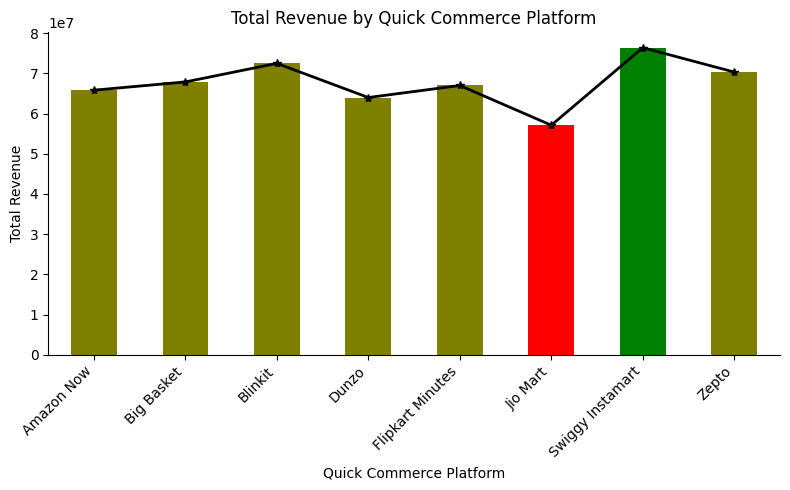

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

max_val = company_revenue.max()
min_val = company_revenue.min()

colors = ["green" if val == max_val else
          "red" if val == min_val else
          "olive"
          for val in company_revenue]

company_revenue.plot(kind="bar", color=colors)
company_revenue.plot(kind="line", color="black", marker="*", linewidth=2)
plt.title("Total Revenue by Quick Commerce Platform")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Quick Commerce Platform")
plt.ylabel("Total Revenue")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

Q.2) Which quick commerce platform has the highest average order value (AOV) ?

In [30]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2,1,3
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12.7,10,Snacks,Cash on Delivery,2,0,3
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4.8,19,Personal Care,Cash on Delivery,3,0,4
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.4,2,Dairy,Credit Card,5,1,5
4,1000005,Dunzo,Mumbai,44,586,12,2.4,13,Household,Wallet,4,0,5


In [31]:
df.groupby("Company")["Order_Value"].mean()

Company
Amazon Now          557.510429
Big Basket          575.065542
Blinkit             609.819198
Dunzo               540.317053
Flipkart Minutes    563.176472
Jio Mart            482.914592
Swiggy Instamart    644.927250
Zepto               593.258314
Name: Order_Value, dtype: float64

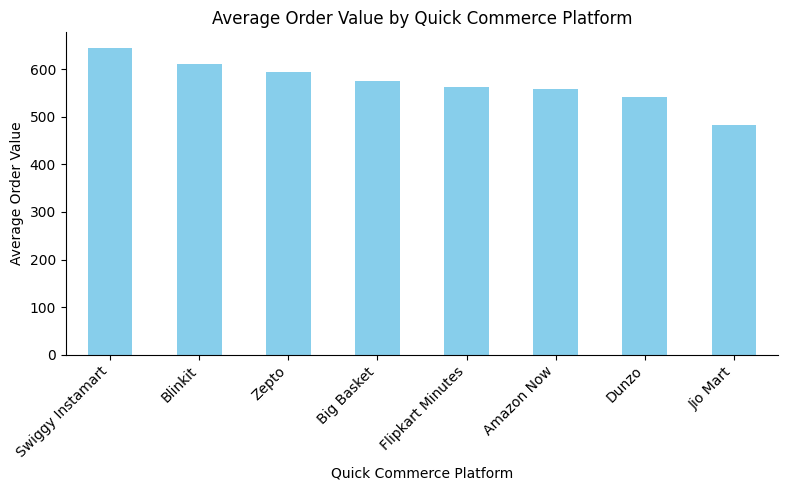

In [32]:
plt.figure(figsize=(8,5))
df.groupby("Company")["Order_Value"].mean().sort_values(ascending=False).plot(kind="bar", color="skyblue")
plt.title("Average Order Value by Quick Commerce Platform")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Quick Commerce Platform")
plt.ylabel("Average Order Value")
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

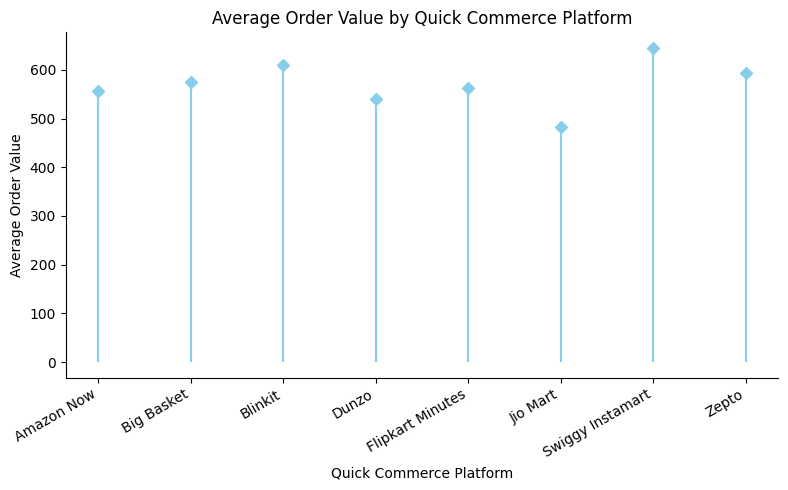

In [33]:
AOV = df.groupby("Company")["Order_Value"].mean()
plt.figure(figsize=(8,5))
plt.stem(AOV.index, AOV.values, linefmt="skyblue", markerfmt="D", basefmt=" ")
plt.title("Average Order Value by Quick Commerce Platform")
plt.xticks(rotation=30, ha="right")
plt.xlabel("Quick Commerce Platform")
plt.ylabel("Average Order Value")
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

Q.3) How does Customer Rating vary across platforms?

In [34]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2,1,3
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12.7,10,Snacks,Cash on Delivery,2,0,3
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4.8,19,Personal Care,Cash on Delivery,3,0,4
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.4,2,Dairy,Credit Card,5,1,5
4,1000005,Dunzo,Mumbai,44,586,12,2.4,13,Household,Wallet,4,0,5


In [35]:
df.groupby("Company")["Customer_Rating"].mean().sort_values(ascending=False)

Company
Blinkit             3.580762
Swiggy Instamart    3.279443
Zepto               3.203062
Big Basket          3.097902
Flipkart Minutes    3.016316
Amazon Now          2.913417
Jio Mart            2.819747
Dunzo               2.428024
Name: Customer_Rating, dtype: float64

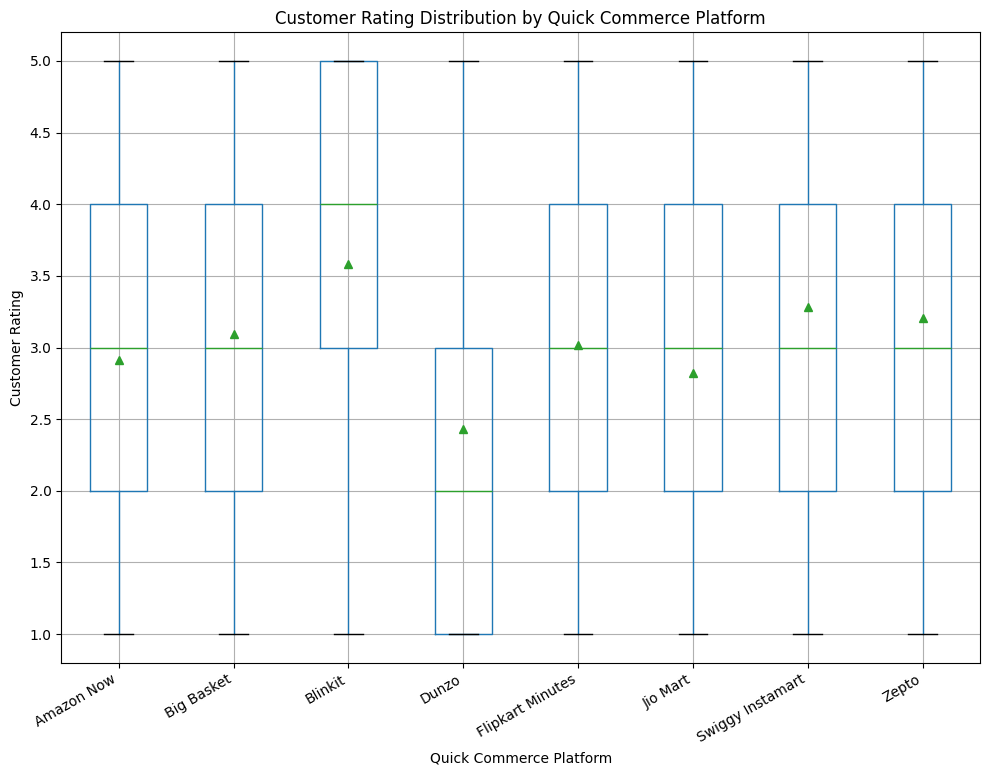

In [36]:
df.boxplot(column="Customer_Rating", by="Company", figsize=(10,8), showmeans=True)
plt.title("Customer Rating Distribution by Quick Commerce Platform")
plt.suptitle("")  # Remove the default title to avoid overlap
plt.xlabel("Quick Commerce Platform")
plt.ylabel("Customer Rating")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [37]:
grouped_rating = df.groupby(["Company","Customer_Rating"]).size().unstack(fill_value=0)
grouped_rating

Customer_Rating,1,2,3,4,5
Company,,,,,
Amazon Now,15977,30351,30866,29697,11192
Big Basket,10143,30339,31020,30908,15637
Blinkit,1060,25553,25561,36708,30005
Dunzo,29818,36280,25377,25818,1170
Flipkart Minutes,12549,30786,31225,30985,13420
Jio Mart,18513,30515,31083,30089,8067
Swiggy Instamart,5000,30278,31039,30931,21227
Zepto,7618,29763,31367,30559,19258


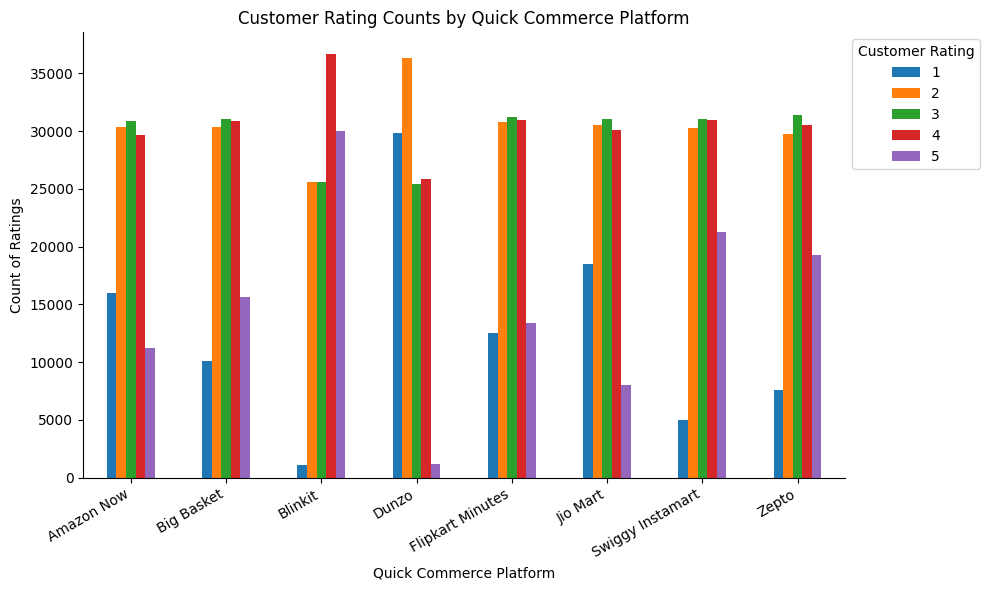

In [38]:
grouped_rating.plot(kind="bar", figsize=(10,6))
plt.title("Customer Rating Counts by Quick Commerce Platform")
plt.xlabel("Quick Commerce Platform")
plt.ylabel("Count of Ratings")
plt.xticks(rotation=30, ha="right")
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.legend(title="Customer Rating", bbox_to_anchor=(1, 1), loc="upper left")
plt.tight_layout()
plt.show()

Q.4) Does "Delivery Time" affects the "Delivery Partner Ratings"?

In [39]:

df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2,1,3
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12.7,10,Snacks,Cash on Delivery,2,0,3
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4.8,19,Personal Care,Cash on Delivery,3,0,4
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.4,2,Dairy,Credit Card,5,1,5
4,1000005,Dunzo,Mumbai,44,586,12,2.4,13,Household,Wallet,4,0,5


In [40]:
df["Delivery_Time_Min"].mean()

np.float64(16.506619875241626)

In [41]:
df["Delivery_Partner_Rating"].mean()

np.float64(3.80029480285982)

In [42]:
# Calculating average rating for delivery timings
x = df.groupby("Delivery_Time_Min")["Delivery_Partner_Rating"].mean()

In [43]:
df["Delivery_Time_Min"].corr(df["Delivery_Partner_Rating"])

np.float64(-0.0027773408026697368)

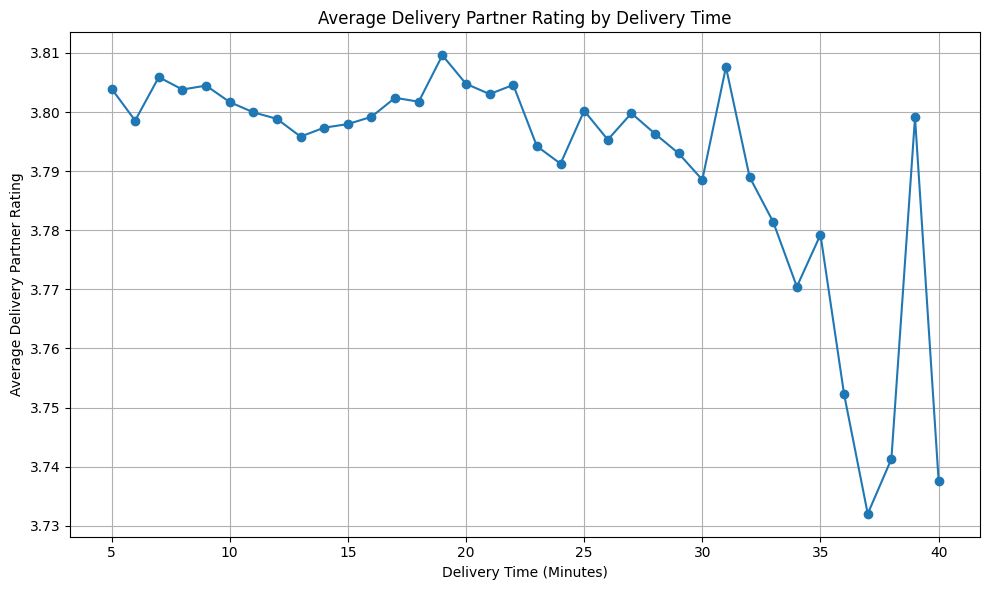

In [44]:
# Line chart 
x.plot(kind="line", marker="o", figsize=(10,6))
plt.title("Average Delivery Partner Rating by Delivery Time")
plt.xlabel("Delivery Time (Minutes)")
plt.ylabel("Average Delivery Partner Rating")
plt.tight_layout()
plt.grid(True)
plt.show()

In [45]:
df["Delivery_Time_Bucket"] = pd.cut(df["Delivery_Time_Min"], 
       bins=[0,10,20,30,40,50], 
       labels=["Very Fast Delivery","Fast Delivery","Normal Delivery",
               "Slow Delivery","Very Slow Delivery"])

In [46]:
df

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Delivery_Time_Bucket
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2,1,3,Fast Delivery
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12.7,10,Snacks,Cash on Delivery,2,0,3,Fast Delivery
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4.8,19,Personal Care,Cash on Delivery,3,0,4,Fast Delivery
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.4,2,Dairy,Credit Card,5,1,5,Very Fast Delivery
4,1000005,Dunzo,Mumbai,44,586,12,2.4,13,Household,Wallet,4,0,5,Fast Delivery
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,1999996,Big Basket,Mumbai,48,72,18,3.0,19,Fruits & Vegetables,Wallet,4,0,3,Fast Delivery
999996,1999997,Swiggy Instamart,Mumbai,33,1510,18,10.5,9,Beverages,Debit Card,4,1,4,Fast Delivery
999997,1999998,Jio Mart,Noida,29,637,18,2.6,6,Groceries,Cash on Delivery,3,0,5,Fast Delivery
999998,1999999,Dunzo,Pune,42,1103,13,7.8,12,Snacks,Wallet,4,1,4,Fast Delivery


In [47]:
bucket_avg = df.groupby("Delivery_Time_Bucket")["Delivery_Partner_Rating"].mean()
bucket_avg

C:\Users\user\AppData\Local\Temp\ipykernel_22996\3093584885.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_avg = df.groupby("Delivery_Time_Bucket")["Delivery_Partner_Rating"].mean()


Delivery_Time_Bucket
Very Fast Delivery    3.803231
Fast Delivery         3.800835
Normal Delivery       3.798345
Slow Delivery         3.783646
Very Slow Delivery         NaN
Name: Delivery_Partner_Rating, dtype: float64

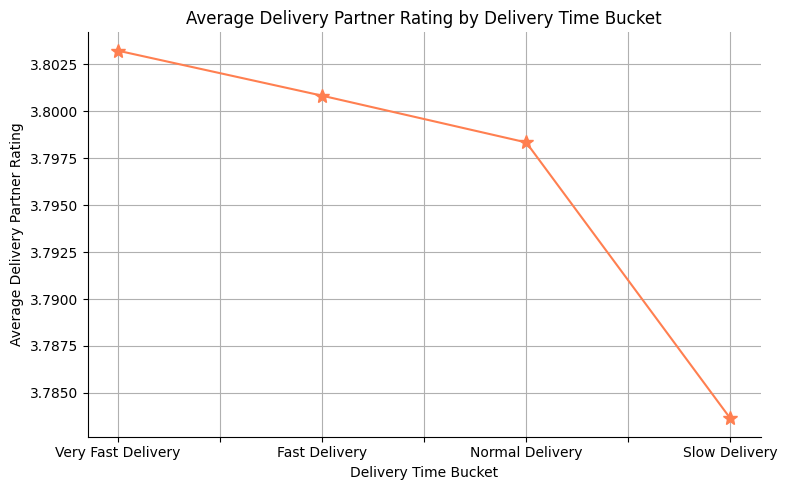

In [48]:
plt.figure(figsize=(8,5))
bucket_avg.plot(kind="line", color="coral", marker="*", markersize=10)
plt.title("Average Delivery Partner Rating by Delivery Time Bucket")
plt.xlabel("Delivery Time Bucket")
plt.ylabel("Average Delivery Partner Rating")
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.grid(True)
plt.show()

Q.5) What is the most popular Product Category on Swiggy Instamart, for the people of age between 30-40, in Mumbai?

In [49]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Delivery_Time_Bucket
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2,1,3,Fast Delivery
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12.7,10,Snacks,Cash on Delivery,2,0,3,Fast Delivery
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4.8,19,Personal Care,Cash on Delivery,3,0,4,Fast Delivery
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.4,2,Dairy,Credit Card,5,1,5,Very Fast Delivery
4,1000005,Dunzo,Mumbai,44,586,12,2.4,13,Household,Wallet,4,0,5,Fast Delivery


In [50]:
df_prod = df[(df["Company"] == "Swiggy Instamart") & 
   ((df["Customer_Age"] >= 30) & (df["Customer_Age"] <= 40)) & 
   (df["City"] == "Mumbai")]

df_prod.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Delivery_Time_Bucket
536,1000537,Swiggy Instamart,Mumbai,38,1157,14,5.7,18,Beverages,Cash on Delivery,4,1,4,Fast Delivery
909,1000910,Swiggy Instamart,Mumbai,32,926,20,14.2,3,Dairy,UPI,2,0,5,Fast Delivery
1203,1001204,Swiggy Instamart,Mumbai,37,234,19,7.6,6,Dairy,Debit Card,5,0,4,Fast Delivery
2918,1002919,Swiggy Instamart,Mumbai,31,423,15,4.0,10,Dairy,Cash on Delivery,2,0,3,Fast Delivery
4251,1004252,Swiggy Instamart,Mumbai,36,50,15,2.2,12,Dairy,Credit Card,3,0,3,Fast Delivery


In [51]:
# Most popular product category
df_prod["Product_Category"].value_counts()

Product_Category
Dairy                  407
Groceries              384
Fruits & Vegetables    375
Snacks                 374
Household              372
Personal Care          343
Beverages              332
Name: count, dtype: int64

Q.6) Which company should these comapny expand into based on performance?

In [52]:
# Group data and apply aggregation function

city_performance = df.groupby(["Company","City"]).agg(Total_Orders=("Order_ID","count"), 
                                   Average_Rating=("Customer_Rating","mean"),
                                   Average_Delivery_Time=("Delivery_Time_Min","mean"),
                                   Total_Revenue=("Order_Value","sum"))
city_performance

Total_Orders  Average_Rating  Average_Delivery_Time  \
Company    City                                                            
Amazon Now Amritsar          9929        2.896666              18.167388   
           Bengluru          9905        3.387683              19.183342   
           Chennai           9847        2.904032              18.138722   
           Delhi             9918        2.989716               8.294616   
           Gurgaon           9797        2.921711              18.166173   
...                           ...             ...                    ...   
Zepto      Jaipur            9678        3.112213              13.145278   
           Kolkata           9825        3.173028               8.302901   
           Mumbai            9861        3.412230              10.152013   
           Noida            10070        3.206653               8.297617   
           Pune              9857        3.188495               8.352643   

                     Total_Revenue  
Company    City                     
Amazon Now Amritsar        5469439  
           Bengluru        5629936  
           Chennai         5363559  
           Delhi           5891026  
           Gurgaon         6680388  
...                            ...  
Zepto      Jaipur          4621428  
           Kolkata         5776955  
           Mumbai          6046485  
           Noida           7070769  
           Pune            5748510  

[96 rows x 4 columns]

In [53]:
best_cities = city_performance[(city_performance["Average_Rating"] >= 3.5) &
                               (city_performance["Average_Delivery_Time"] <= 15) &
                               (city_performance["Total_Orders"] > city_performance["Total_Orders"].median()) 
                               ].reset_index().sort_values(by="Total_Revenue", ascending=False)
best_cities

,Company,City,Total_Orders,Average_Rating,Average_Delivery_Time,Total_Revenue
2,Blinkit,Gurgaon,10078,3.579381,14.199345,7374774
5,Zepto,Bengluru,9971,3.598636,9.198977,6041668
0,Blinkit,Amritsar,9932,3.589106,14.199154,6006361
3,Blinkit,Kolkata,10004,3.566873,14.142743,6003384
4,Blinkit,Pune,9908,3.583266,14.164110,5930415
1,Blinkit,Chennai,9876,3.580903,14.135581,5921870


In [54]:
best_cities[["Company","City"]]

,Company,City
2,Blinkit,Gurgaon
5,Zepto,Bengluru
0,Blinkit,Amritsar
3,Blinkit,Kolkata
4,Blinkit,Pune
1,Blinkit,Chennai


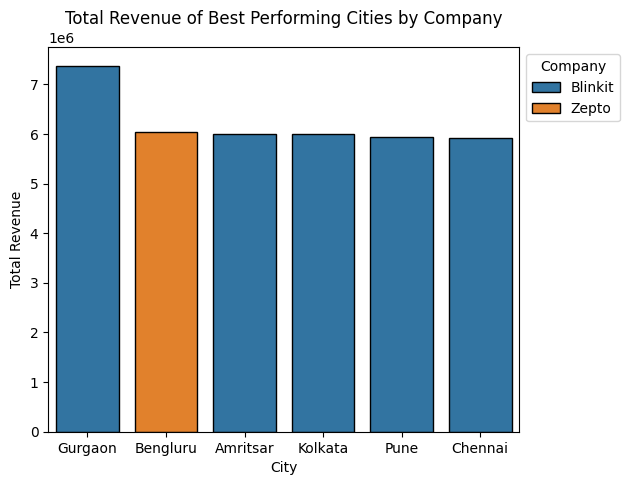

In [55]:
sns.barplot(data=best_cities, x="City", y="Total_Revenue", hue="Company", edgecolor="black")
plt.legend(title="Company", bbox_to_anchor=(1, 1), loc="upper left")
plt.title("Total Revenue of Best Performing Cities by Company")
plt.xlabel("City")
plt.ylabel("Total Revenue")
ax = plt.gca()
plt.tight_layout()
plt.show()

Q.7) Are discounts increasing order volume or just reducing revenue?

In [56]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Delivery_Time_Bucket
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2,1,3,Fast Delivery
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12.7,10,Snacks,Cash on Delivery,2,0,3,Fast Delivery
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4.8,19,Personal Care,Cash on Delivery,3,0,4,Fast Delivery
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.4,2,Dairy,Credit Card,5,1,5,Very Fast Delivery
4,1000005,Dunzo,Mumbai,44,586,12,2.4,13,Household,Wallet,4,0,5,Fast Delivery


In [57]:
df["Discount_Applied"].value_counts()

Discount_Applied
0    567906
1    379846
Name: count, dtype: int64

In [58]:
discount_order_value = df.groupby("Discount_Applied")["Order_Value"].mean()
discount_order_value

Discount_Applied
0    476.417152
1    712.190830
Name: Order_Value, dtype: float64

In [59]:
discount_items_counts = df.groupby("Discount_Applied")["Items_Count"].sum()
discount_items_counts

Discount_Applied
0    5854258
1    3920185
Name: Items_Count, dtype: int64

In [62]:
df["Discount_Applied"].unique()

array([1, 0])

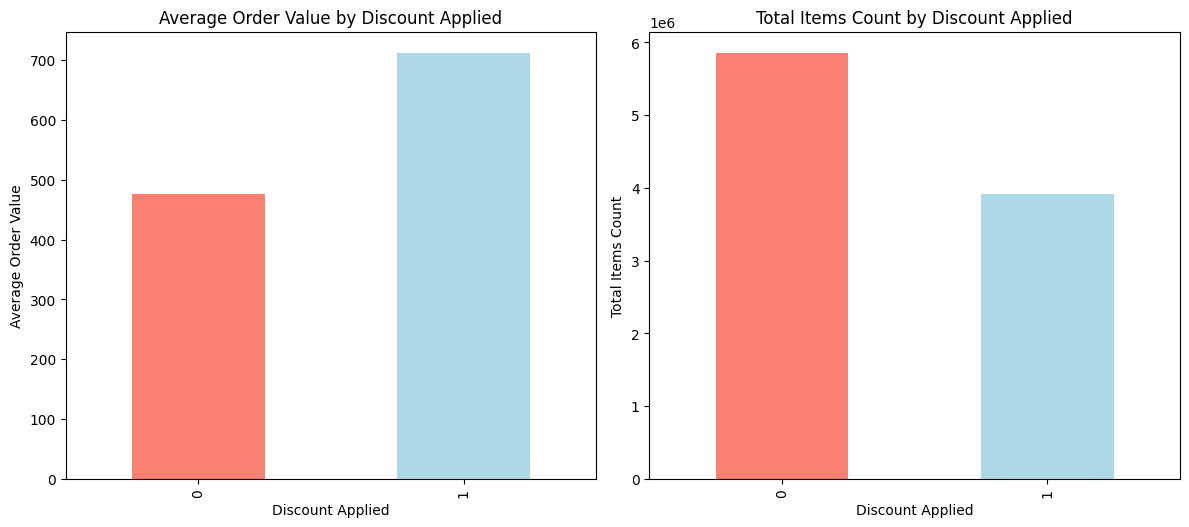

In [64]:
plt.figure(figsize=(12,10))

plt.subplot(2,2,1)
discount_order_value.plot(kind="bar", color=["salmon","lightblue"])
plt.title("Average Order Value by Discount Applied")
plt.xlabel("Discount Applied")
plt.ylabel("Average Order Value")
plt.tight_layout()

plt.subplot(2,2,2)
discount_items_counts.plot(kind="bar", color=["salmon","lightblue"])
plt.title("Total Items Count by Discount Applied")
plt.xlabel("Discount Applied")
plt.ylabel("Total Items Count")
plt.tight_layout()

plt.show()